In [12]:
import os
import numpy as np

import matplotlib.pyplot as plt
import pickle
from spectral.io import envi
from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

os.chdir('/store/carroll/col/data/')

%matplotlib widget

In [16]:
wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('wl_nan.txt')

In [4]:
os.listdir('2018/rccs/')

['.ipynb_checkpoints',
 'alg_rfl_blueline_postproces_withtrend_20250903.txt',
 'analytical_rfl_blueline_interp_20250908.txt',
 'analytical_rfl_blueline_postproces_withtrend_20250903.txt',
 'bright_dark',
 'cal_tarp',
 'modtran',
 'rcc_frankenstein_20250908.txt',
 'rcc_white_tarp_mean_20250829.txt',
 'rcc_white_tarp_mean_postprocess_detrended_20250903_wholeswir2.txt',
 'rcc_white_tarp_mean_postprocess_withtrend_20250829.txt',
 'rcc_white_tarp_mean_postprocess_withtrend_20250903_wholeswir2.txt',
 'rccs_white_tarp_20250829.pkl']

In [5]:
rccs = np.loadtxt('2018/rccs/rcc_frankenstein_20250908.txt')

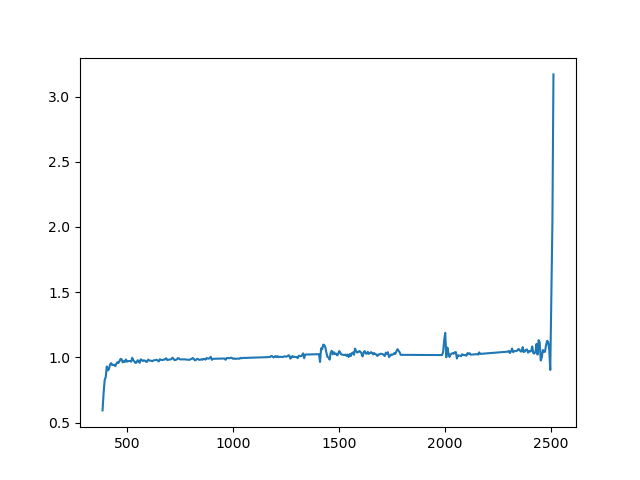

In [10]:
fig = plt.figure()
plt.plot(wl, rccs)
plt.show()

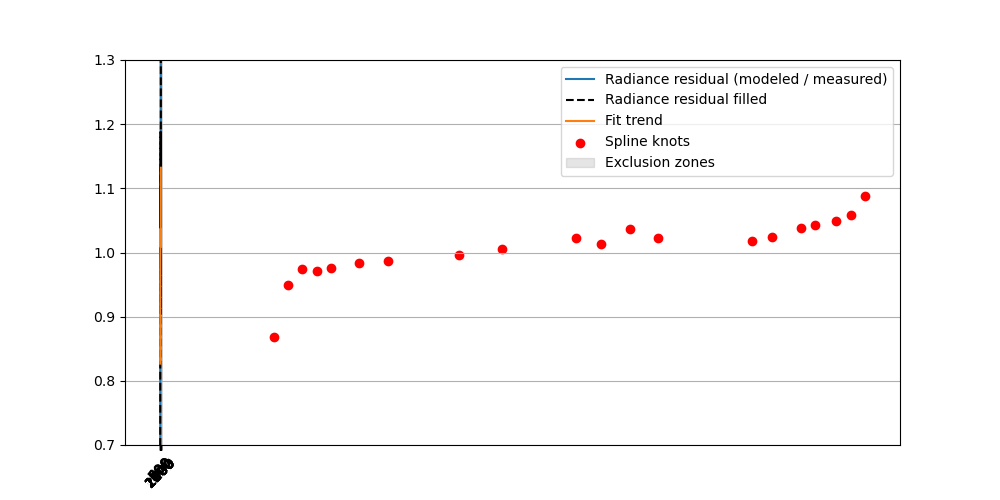

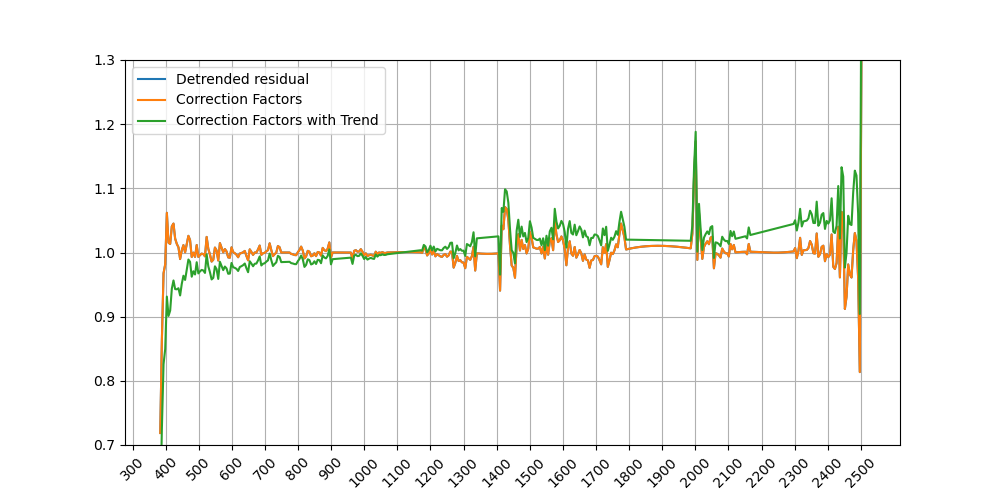

In [19]:
# detrend
# wl = wl/1000

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

radiance_ratio = rccs

radiance_ratio_adjusted = radiance_ratio.copy()
knots = np.array([400,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.*1000
ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.640,1.670], [1.79, 1.99], # water absorption regions (narrower)
                # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
                [0.669, 0.679],
                [2.096, 2.350]] # identified systematics - most conservative
               # [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics - less conservative

knot_average_window = 1

for a, b in ignore_zones:
    wl_subset = wl[np.logical_and(wl > a, wl < b)]
    radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)

inds = np.array([wl2ind(q) for q in knots])
spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
spline = splrep(knots,spline_y)
y_trend  = splev(wl, spline)


y_detrend = radiance_ratio/y_trend
y_correction = radiance_ratio/y_trend
for ez in ignore_zones:
    y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
    y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])


plt.figure(figsize=(10, 5))
plt.plot(wl, radiance_ratio, label='Radiance residual (modeled / measured)')
plt.plot(wl, radiance_ratio_adjusted, label='Radiance residual filled', c='black',ls='--')
plt.plot(wl, y_trend, label='Fit trend')
plt.scatter(knots*1000, spline_y, color='r', label='Spline knots')
for _el, el in enumerate(ignore_zones):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2)

plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(wl, y_detrend, label='Detrended residual')
plt.plot(wl, y_correction, label='Correction Factors')
plt.plot(wl, y_correction*y_trend, label='Correction Factors with Trend')
plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()